In [1]:
import torch
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import json
import matplotlib.pyplot as plt
from torchvision.models import ResNet101_Weights

# 사전학습된 가중치 불러오기
weights = ResNet101_Weights.DEFAULT
model = models.resnet101(weights=weights)
print(model)
CLASSES = json.load(open('./data/imagenet_classes.json'))
idx2class = [CLASSES[str(i)] for i in range(1000)]

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /Users/ihanjo/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 94.5MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
idx2class

['tench, Tinca tinca',
 'goldfish, Carassius auratus',
 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias',
 'tiger shark, Galeocerdo cuvieri',
 'hammerhead, hammerhead shark',
 'electric ray, crampfish, numbfish, torpedo',
 'stingray',
 'cock',
 'hen',
 'ostrich, Struthio camelus',
 'brambling, Fringilla montifringilla',
 'goldfinch, Carduelis carduelis',
 'house finch, linnet, Carpodacus mexicanus',
 'junco, snowbird',
 'indigo bunting, indigo finch, indigo bird, Passerina cyanea',
 'robin, American robin, Turdus migratorius',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel, dipper',
 'kite',
 'bald eagle, American eagle, Haliaeetus leucocephalus',
 'vulture',
 'great grey owl, great gray owl, Strix nebulosa',
 'European fire salamander, Salamandra salamandra',
 'common newt, Triturus vulgaris',
 'eft',
 'spotted salamander, Ambystoma maculatum',
 'axolotl, mud puppy, Ambystoma mexicanum',
 'bullfrog, Rana catesbeiana',
 'tree frog, tree-f

In [5]:
img = Image.open('./data/corgie.jpg')

In [ ]:
img

In [13]:
tr = transforms.Compose([transforms.Resize((224, 224), Image.BICUBIC),
                         transforms.ToTensor()])
img_tr = tr(img)
img_tr = img_tr.unsqueeze(0)
img_tr.size()

torch.Size([1, 3, 224, 224])

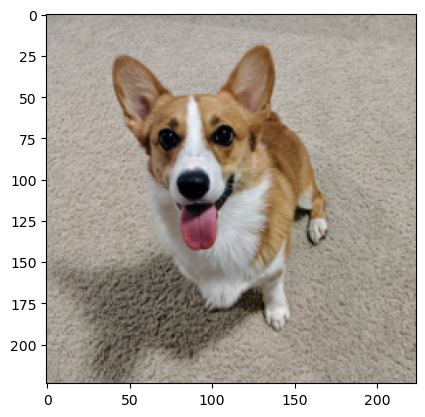

In [33]:
v_img = img_tr.squeeze(0).detach()
v_img = v_img.transpose(0, 2).transpose(0, 1).numpy()
plt.imshow(v_img)

In [19]:
py = model(img_tr).max(1, keepdim=False)[1]
idx = py.item()

In [20]:
idx2class[idx]

'Pembroke, Pembroke Welsh corgi'

In [21]:
# 이미지 변경
def f(img, es, gr):
    sign_gr = gr.sign()
    per_img = img+es*sign_gr
    torch.clamp(per_img, 0, 1)
    return per_img

In [22]:
img_tr.requires_grad_(True)

tensor([[[[0.6314, 0.6353, 0.6353,  ..., 0.6902, 0.6627, 0.6431],
          [0.6275, 0.6627, 0.6353,  ..., 0.6627, 0.6627, 0.6118],
          [0.6510, 0.6275, 0.6353,  ..., 0.6235, 0.6980, 0.6784],
          ...,
          [0.6549, 0.6314, 0.6118,  ..., 0.6275, 0.6627, 0.6902],
          [0.6588, 0.6863, 0.6902,  ..., 0.6431, 0.6588, 0.6392],
          [0.6392, 0.6627, 0.6824,  ..., 0.6275, 0.6392, 0.7059]],

         [[0.6157, 0.6196, 0.6196,  ..., 0.6627, 0.6353, 0.6235],
          [0.6118, 0.6431, 0.6196,  ..., 0.6353, 0.6353, 0.5843],
          [0.6353, 0.6118, 0.6196,  ..., 0.5961, 0.6706, 0.6510],
          ...,
          [0.6157, 0.5922, 0.5765,  ..., 0.6000, 0.6353, 0.6588],
          [0.6196, 0.6510, 0.6549,  ..., 0.6118, 0.6235, 0.6078],
          [0.6000, 0.6314, 0.6431,  ..., 0.6039, 0.6157, 0.6824]],

         [[0.5804, 0.5843, 0.5843,  ..., 0.6275, 0.6000, 0.5882],
          [0.5765, 0.6118, 0.5843,  ..., 0.5922, 0.5961, 0.5490],
          [0.6000, 0.5804, 0.5804,  ..., 0

In [27]:
out = model(img_tr)
loss = F.nll_loss(out, torch.tensor([263]))

model.zero_grad()
loss.backward()

gr = img_tr.grad.data

es = 0.03
pe_data = f(img_tr, es, gr)
out = model(pe_data)

In [28]:
out

tensor([[-1.2197e-01,  7.4134e-02, -1.9023e-01, -4.2487e-01, -1.4411e-01,
         -1.2493e-01, -1.6425e-01,  6.8161e-02,  5.7310e-02, -2.2486e-01,
          3.8527e-01,  4.2625e-01,  4.6680e-02,  5.8054e-02,  1.1399e-01,
          1.4551e-01,  2.8574e-01,  2.8733e-01,  1.0032e-01,  9.4865e-02,
          1.5416e-01, -8.7680e-02, -1.7148e-01,  1.7462e-01, -7.0466e-02,
          1.5095e-02, -3.2446e-01, -1.3486e-01,  9.4510e-02, -1.1545e-01,
         -3.4129e-01, -1.4790e-01, -2.2255e-01, -9.9268e-02, -4.3380e-02,
         -1.0643e-01, -3.7651e-02, -1.9303e-01, -1.8656e-01,  1.1763e-01,
          1.7661e-01, -9.9494e-02, -6.7562e-02, -3.0299e-01, -2.2708e-01,
         -1.9667e-01,  3.3933e-02,  8.2530e-03, -2.4415e-01, -1.6857e-01,
         -2.5232e-01,  1.2322e-01, -4.3301e-01, -2.5968e-01, -2.8050e-01,
         -5.0364e-02, -1.9392e-01, -2.1263e-01,  5.8829e-02,  1.1568e-01,
          1.8403e-01, -8.6965e-02, -3.7331e-02, -2.2224e-01,  5.1602e-02,
         -1.6348e-02, -8.7949e-02, -2.

In [30]:
idx

263

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


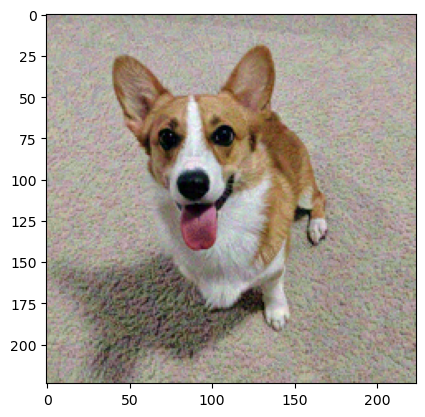

In [32]:
v_img = pe_data.squeeze(0).detach()
v_img = v_img.transpose(0, 2).transpose(0, 1).numpy()
plt.imshow(v_img)

In [2]:
import os
import urllib.request
import gdown
import tarfile

In [3]:
down_dir = '../../data'
url = 'https://drive.google.com/file/d/1HQ-IfGc2zsT6eqvuAE6ZnZyiHXJ09UjA/view?usp=drive_link'
target = os.path.join(down_dir, 'VOCtrainval_11-May-2012.tar')
os.makedirs(down_dir, exist_ok=True)
if not os.path.exists(target):
    gdown.download(url, target, quiet=False, fuzzy=True)
    # urllib.request.urlretrieve(url, target)
    with tarfile.open(target) as tar:
        tar.extractall(down_dir)

Downloading...
From (original): https://drive.google.com/uc?id=1HQ-IfGc2zsT6eqvuAE6ZnZyiHXJ09UjA
From (redirected): https://drive.google.com/uc?id=1HQ-IfGc2zsT6eqvuAE6ZnZyiHXJ09UjA&confirm=t&uuid=e163db82-792d-45ba-8e48-c4af8244059a
To: /Users/ihanjo/Library/CloudStorage/GoogleDrive-aijnjj12@gmail.com/내 드라이브/인공지능 사관학교/Coding/data/VOCtrainval_11-May-2012.tar
100%|██████████| 2.00G/2.00G [02:10<00:00, 15.3MB/s]
